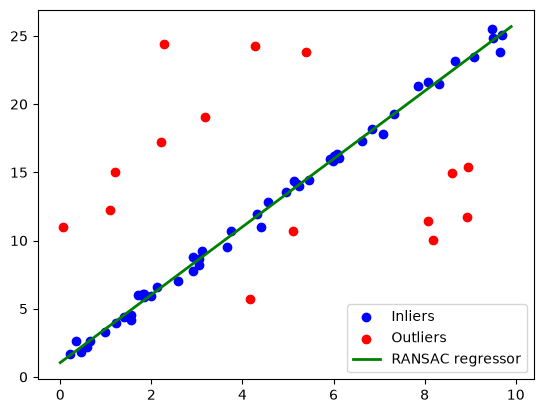

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression

# 1. 데이터 생성 (Inlier + Outlier)
np.random.seed(42)
x = np.random.rand(50, 1) * 10
y = 2.5 * x + 1 + np.random.randn(50, 1) * 0.5  # 정상치 (Inlier)

# 이상치(Outlier) 추가
x_outlier = np.random.rand(15, 1) * 10
y_outlier = np.random.rand(15, 1) * 20 + 5 

X = np.vstack((x, x_outlier))
Y = np.vstack((y, y_outlier))

# 2. RANSAC 모델 학습
ransac = RANSACRegressor(estimator=LinearRegression(), 
                         min_samples=2, 
                         residual_threshold=2.0, 
                         max_trials=100, 
                         random_state=42)
ransac.fit(X, Y)

# 3. Inlier와 Outlier 구분
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

# 4. 시각화
line_X = np.arange(0, 10, 0.1)[:, np.newaxis]
line_Y = ransac.predict(line_X)

plt.scatter(X[inlier_mask], Y[inlier_mask], color='blue', label='Inliers')
plt.scatter(X[outlier_mask], Y[outlier_mask], color='red', label='Outliers')
plt.plot(line_X, line_Y, color='green', linewidth=2, label='RANSAC regressor')
plt.legend()
plt.show()
